# 03 — Exame médico (Breast Cancer Wisconsin Diagnostic)

Classe positiva: **é maligno?** (`target = 1`). Base pequena: todas as proporções vêm acompanhadas das contagens absolutas.

In [1]:
# Configuração do ambiente (Google Colab). Fora do Colab, usa a pasta local do projeto.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/a2'   # fácil de trocar
    IN_COLAB = True
except ImportError:
    import os
    PROJECT_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
    IN_COLAB = False
%cd {PROJECT_DIR}
if IN_COLAB:
    !pip install -q -r requirements.txt
import sys; sys.path.insert(0, PROJECT_DIR)

C:\Users\otavi\OneDrive\Desktop\data science\a2


In [2]:
DOMAIN = "exame_medico"
FORCE_RETRAIN = False   # True = ignora os checkpoints em outputs/exame_medico/models/ e retreina

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src import config, cutoff_hist, evaluate, explain, pipeline
from src.pipeline import timed

cfg = config.DOMAINS[DOMAIN]
OUT = config.output_dir(DOMAIN)
FX = OUT / "faixas"
T = config.THRESHOLD
FIGS = []

def show(path):
    """Registra a figura para o resumo e exibe no notebook."""
    FIGS.append(path.relative_to(OUT).as_posix())
    display(Image(filename=str(path)))

def table(df, stem):
    """Salva CSV + Markdown em outputs/<dominio>/ e exibe."""
    evaluate.save_table(df, OUT / stem)
    display(evaluate.round_table(df))

print(f"Domínio: {DOMAIN} | classe positiva: {cfg['positive_question']} | "
      f"métrica-alvo: {cfg['target_metric']} | limiar das métricas: {T}")

Domínio: exame_medico | classe positiva: é maligno? | métrica-alvo: roc_auc | limiar das métricas: 0.5


## 1. Carregar os dados

In [3]:
with timed("carregar dados"):
    X, y = pipeline.load_domain_data(DOMAIN)
print(f"X: {X.shape} | positivos (target = 1): {y.sum()} ({100 * y.mean():.2f}%)")

[tempo] carregar dados: 0.0 s
X: (569, 30) | positivos (target = 1): 212 (37.26%)


In [4]:
# Conferência: no sklearn 0 = maligno; prepare_data inverteu para 1 = maligno (~37%)
from sklearn.datasets import load_breast_cancer
orig = load_breast_cancer()
n_malignos = int((orig.target == 0).sum())
assert y.sum() == n_malignos, "target = 1 deveria ser maligno"
print(f"OK: target = 1 corresponde a maligno ({y.sum()} de {len(y)} = {100 * y.mean():.2f}%)")

OK: target = 1 corresponde a maligno (212 de 569 = 37.26%)


## 2. Balanceamento das classes

,classe,n,pct_do_total
0,1 = maligno (é maligno?),212,37.26
1,0 = benigno,357,62.74
2,Total,569,100.00


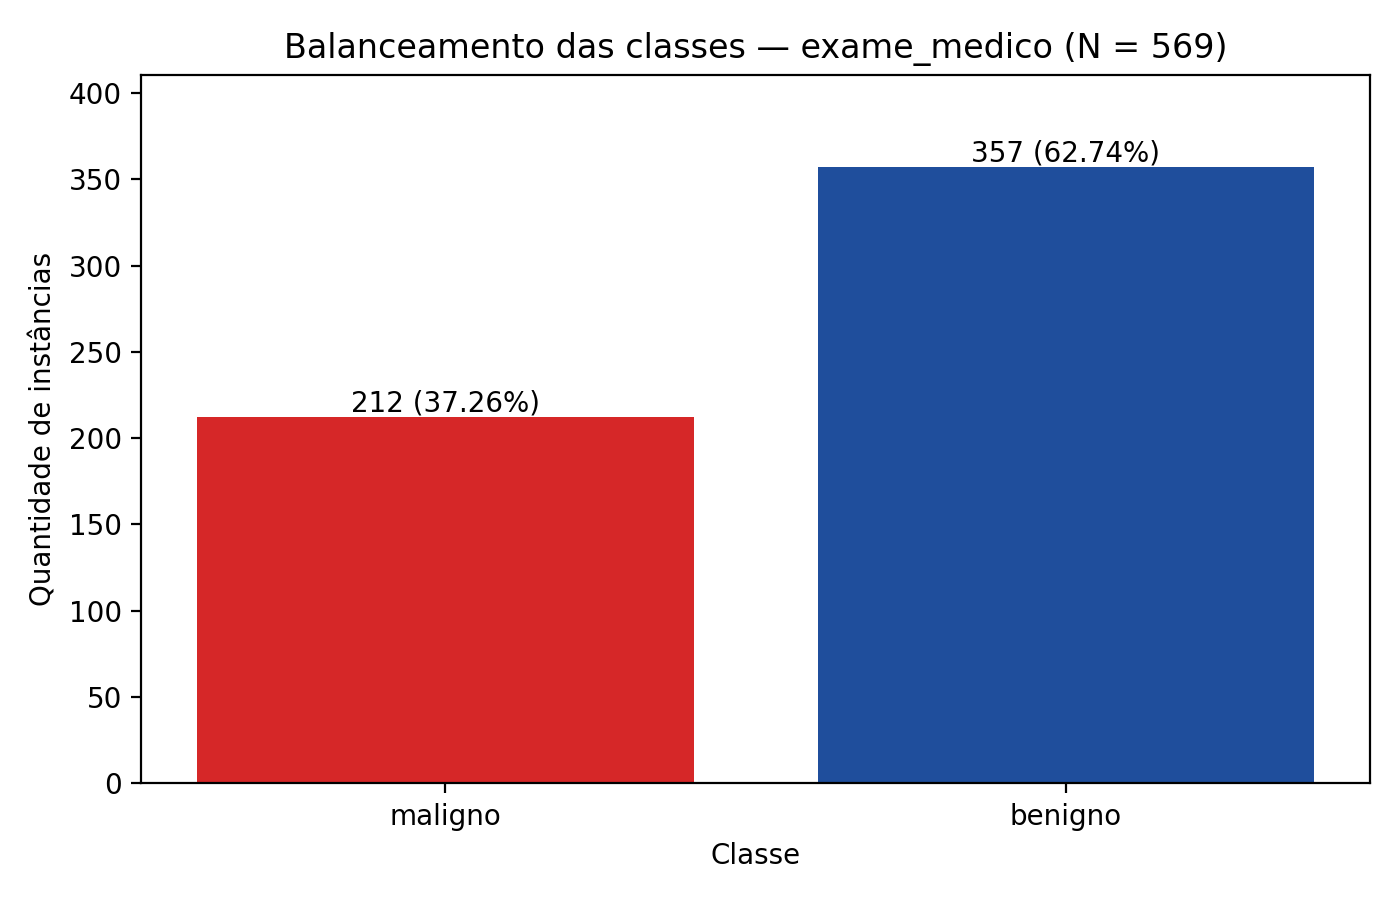

In [5]:
balanceamento = evaluate.class_balance_table(y, cfg)
table(balanceamento, "balanceamento")
show(evaluate.plot_class_balance(y, cfg, OUT / "01_balanceamento_classes.png",
                                 f"Balanceamento das classes — {DOMAIN} (N = {len(y)})"))

## 3. Split estratificado 60/20/20 (treino / validação / teste)

In [6]:
with timed("split"):
    splits = pipeline.split_data(X, y)
X_tr, y_tr = splits["treino"]
X_val, y_val = splits["validacao"]
X_te, y_te = splits["teste"]
table(pipeline.split_table(splits), "split")

[tempo] split: 0.0 s


,conjunto,n,pct_do_total,n_positivos,pct_positivos,n_negativos
0,treino,341,59.93,127,37.24,214
1,validacao,114,20.04,43,37.72,71
2,teste,114,20.04,42,36.84,72


## 4. Tuning por validação cruzada (somente no treino)

Pipeline completo (pré-processamento + modelo) dentro da busca; `StratifiedKFold(n_splits=5, shuffle=True)`. Checkpoint em `models/`.

In [7]:
tuned = pipeline.tune_all(DOMAIN, X_tr, y_tr, force_retrain=FORCE_RETRAIN)
hiperparametros = pipeline.hyperparams_table(tuned, cfg["target_metric"])
table(hiperparametros, "hiperparametros")

[checkpoint] Regressão Logística: carregado de regressao_logistica.joblib
[tempo] tuning Regressão Logística: 0.0 s
[checkpoint] Random Forest: carregado de random_forest.joblib
[tempo] tuning Random Forest: 0.0 s
[checkpoint] SVC (RBF): carregado de svc__rbf.joblib
[tempo] tuning SVC (RBF): 0.0 s


,modelo,metrica_cv,cv_roc_auc_media,cv_roc_auc_desvio,cv_folds,candidatos_testados,tempo_tuning_s,melhores_hiperparametros
0,Regressão Logística,roc_auc,0.9941,0.0078,5,6,28.0622,C=1
1,Random Forest,roc_auc,0.9874,0.0100,5,48,17.8298,max_depth=8; max_features=sqrt; min_samples_le...
2,SVC (RBF),roc_auc,0.9941,0.0083,5,16,0.2136,C=10; gamma=0.01


## 5. Comparação dos modelos na validação (limiar = 0,5 nas métricas de decisão)

[tempo] avaliação na validação: 0.0 s


,modelo,limiar,acuracia,precisao,recall,f1,roc_auc,pr_auc_trapezoidal,average_precision_AP,TN,FP,FN,TP
0,Regressão Logística,0.5,0.9737,0.9545,0.9767,0.9655,0.9957,0.9946,0.9946,69,2,1,42
1,Random Forest,0.5,0.9737,0.9762,0.9535,0.9647,0.9885,0.9864,0.9865,70,1,2,41
2,SVC (RBF),0.5,0.9649,0.9333,0.9767,0.9545,0.9957,0.9946,0.9946,68,3,1,42


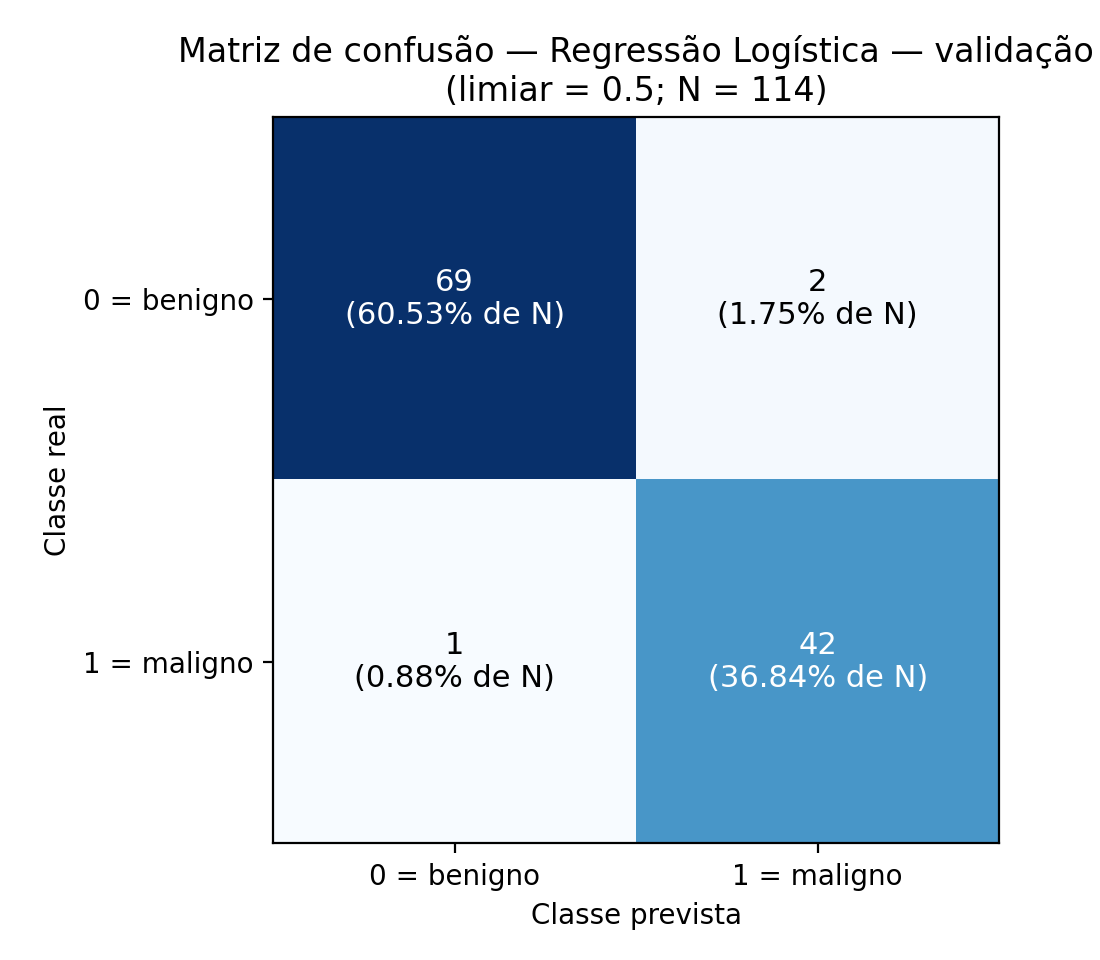

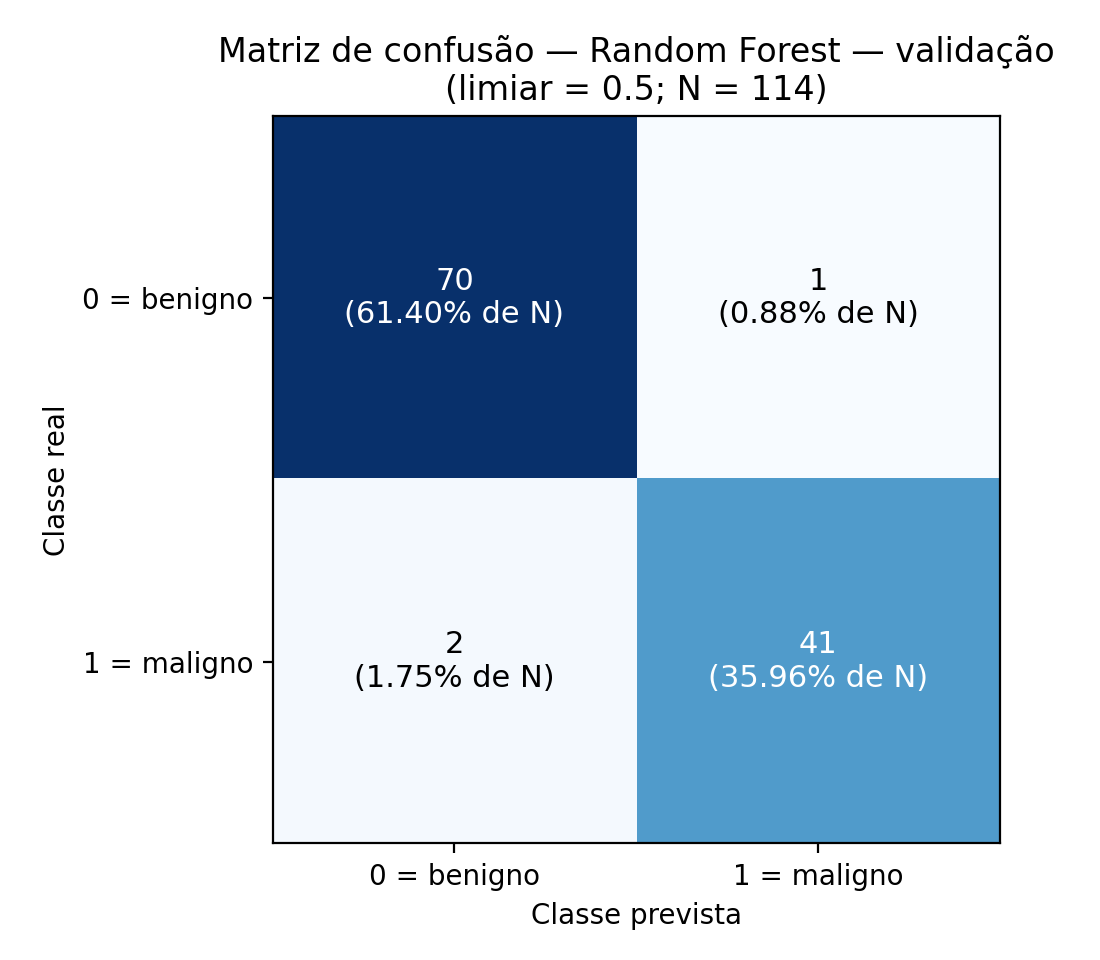

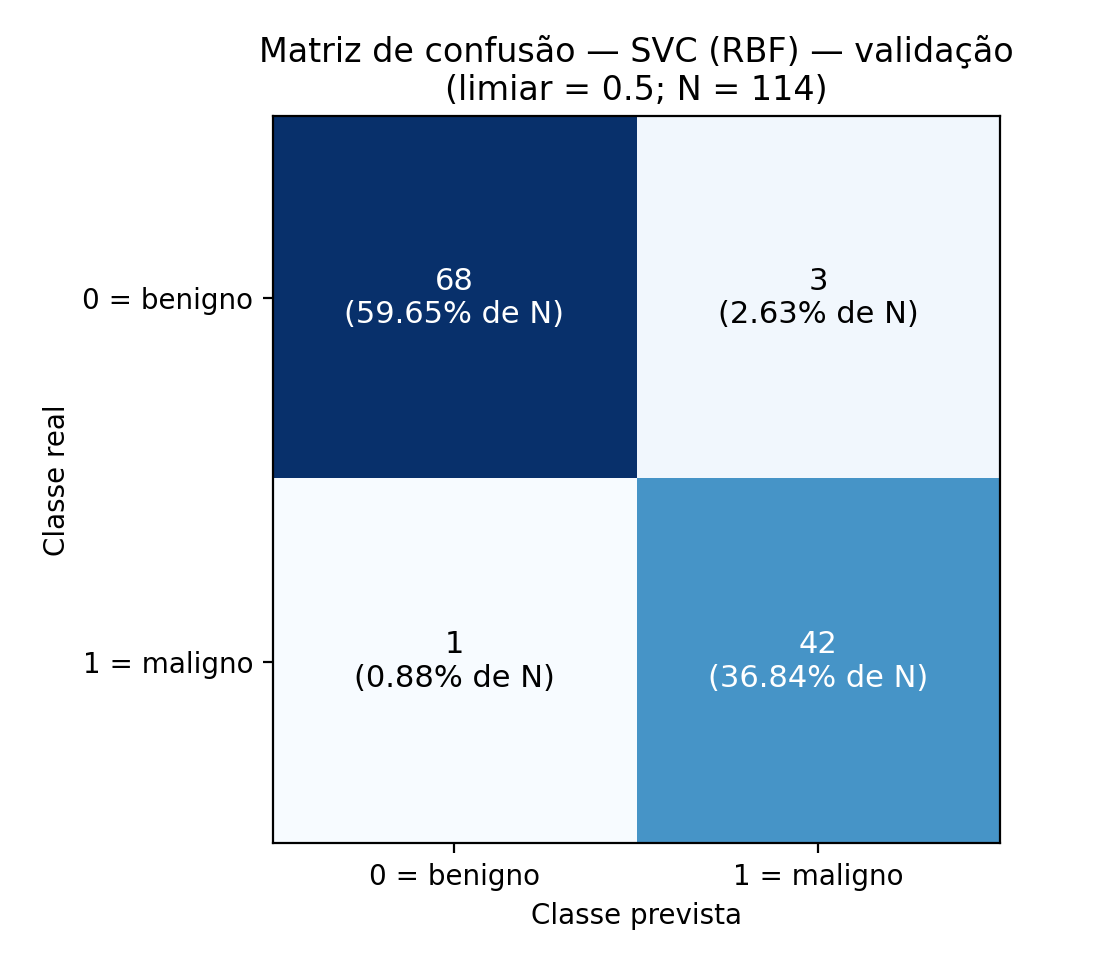

In [8]:
with timed("avaliação na validação"):
    val_probas = {name: pipeline.predict_positive(ck["estimator"], X_val)
                  for name, ck in tuned.items()}
    comparacao = evaluate.comparison_table(y_val, val_probas)
table(comparacao, "comparacao_validacao")
for name, p in val_probas.items():
    show(evaluate.plot_confusion(
        y_val, p, cfg, OUT / f"02_matriz_confusao_validacao_{pipeline.slug(name)}.png",
        f"Matriz de confusão — {name} — validação"))

## 6. Seleção do melhor modelo (métrica-alvo na validação)

In [9]:
best_name, best_col, best_value = evaluate.select_best(comparacao, cfg["target_metric"])
best = tuned[best_name]["estimator"]
selecao = f"{best_name} — maior {best_col} na validação = {best_value:.4f}"
print("Melhor modelo:", selecao)

Melhor modelo: Regressão Logística — maior roc_auc na validação = 0.9957


## 7. Curvas ROC e PR na validação

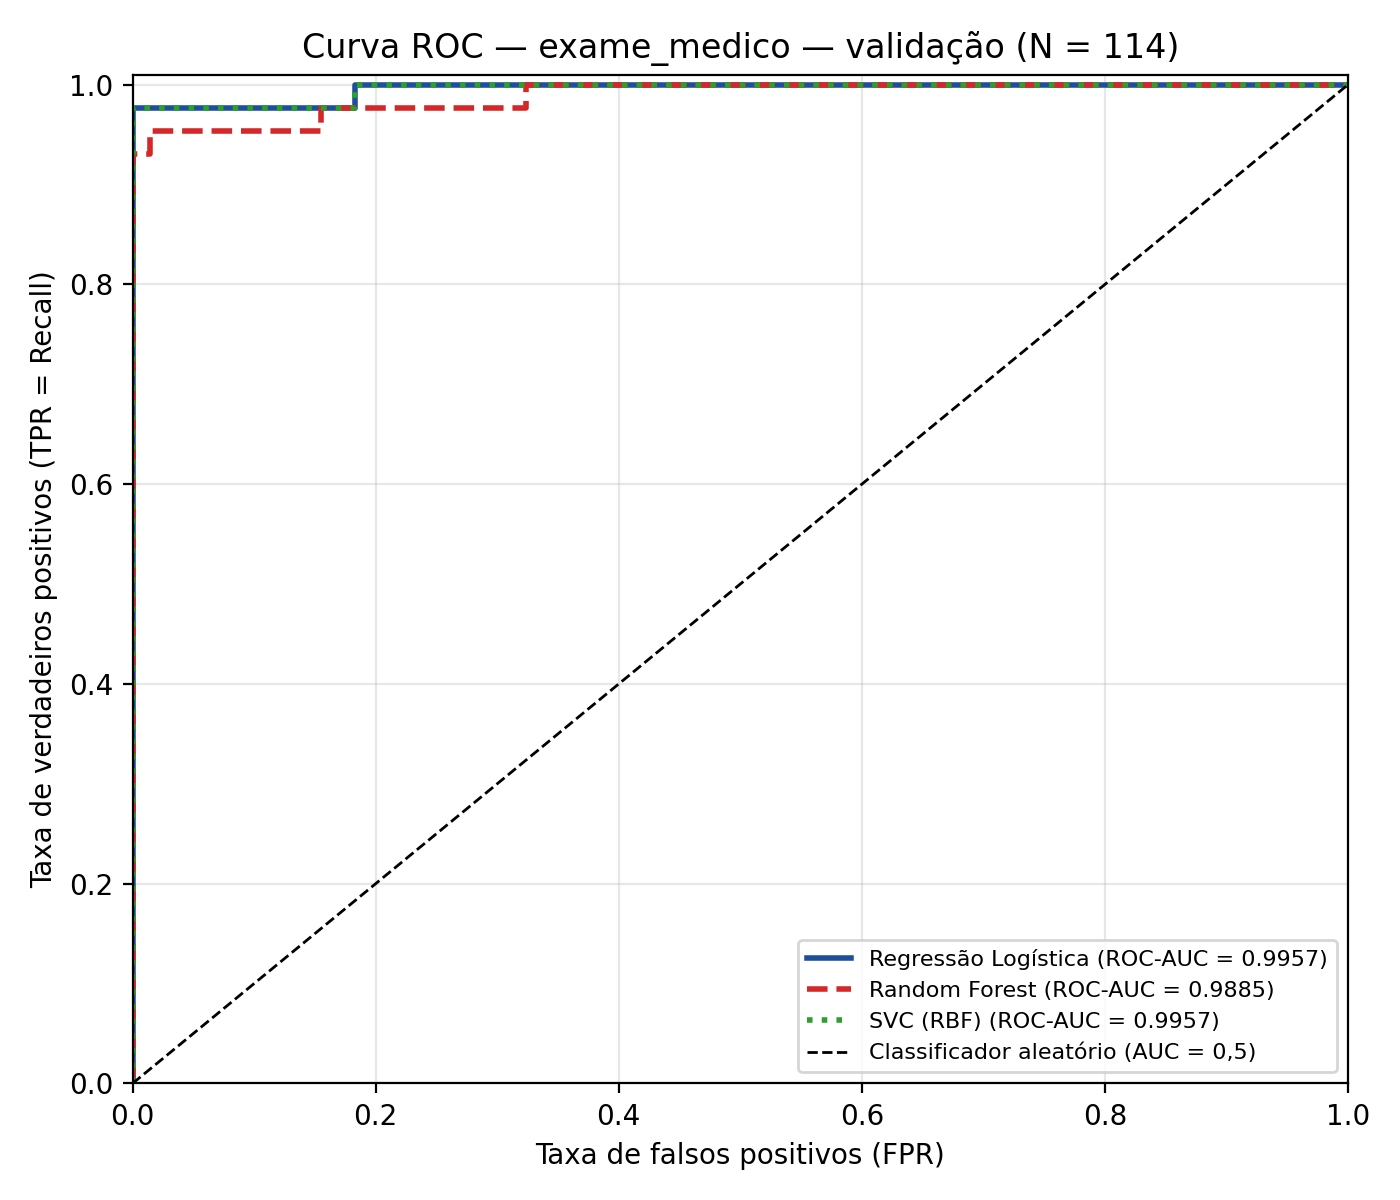

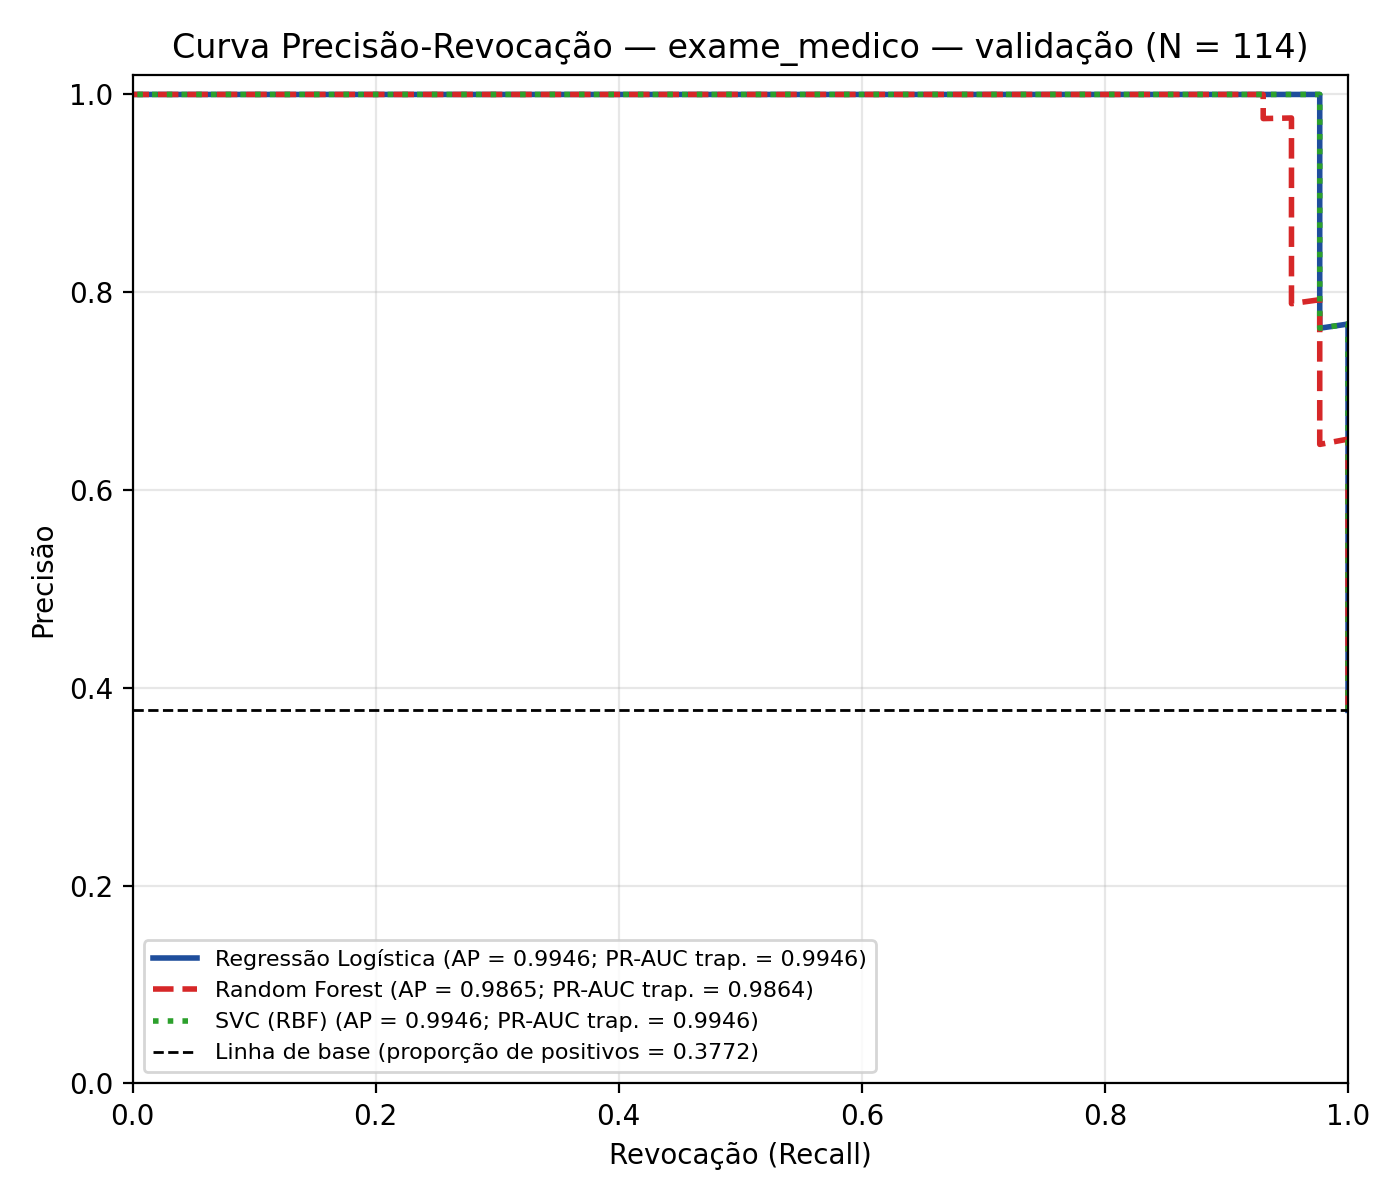

In [10]:
n_val = len(y_val)
show(evaluate.plot_roc(y_val, val_probas, OUT / "03_curva_roc_validacao.png",
                       f"Curva ROC — {DOMAIN} — validação (N = {n_val})"))
show(evaluate.plot_pr(y_val, val_probas, OUT / "04_curva_pr_validacao.png",
                      f"Curva Precisão-Revocação — {DOMAIN} — validação (N = {n_val})"))

## 8. Varredura de limiar do melhor modelo (validação)

In [11]:
varredura = evaluate.threshold_sweep(y_val, val_probas[best_name])
table(varredura, "varredura_limiar")

,limiar,TP,FP,TN,FN,TPR_recall,FPR,precisao
0,0.1,43,13,58,0,1.0000,0.1831,0.7679
1,0.2,42,8,63,1,0.9767,0.1127,0.8400
2,0.3,42,4,67,1,0.9767,0.0563,0.9130
3,0.4,42,2,69,1,0.9767,0.0282,0.9545
4,0.5,42,2,69,1,0.9767,0.0282,0.9545
5,0.6,42,2,69,1,0.9767,0.0282,0.9545
6,0.7,42,0,71,1,0.9767,0.0000,1.0000
7,0.8,42,0,71,1,0.9767,0.0000,1.0000
8,0.9,42,0,71,1,0.9767,0.0000,1.0000


## 9. Avaliação final no teste (melhor modelo, sem retreinar e sem ajustes)

[tempo] avaliação no teste: 0.0 s


,modelo,conjunto,limiar,acuracia,precisao,recall,f1,roc_auc,pr_auc_trapezoidal,average_precision_AP,TN,FP,FN,TP
0,Regressão Logística,teste,0.5,0.9737,0.9756,0.9524,0.9639,0.9954,0.9935,0.9936,71,1,2,40


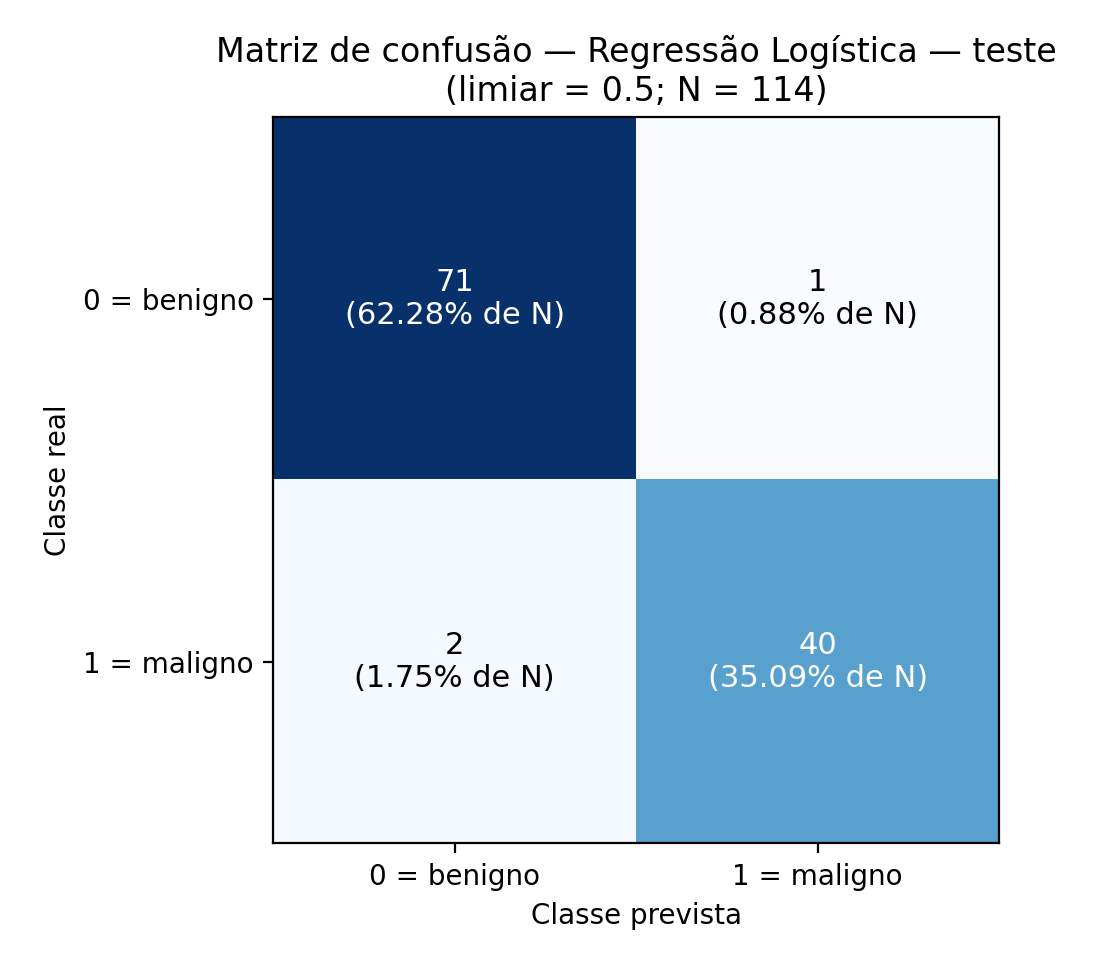

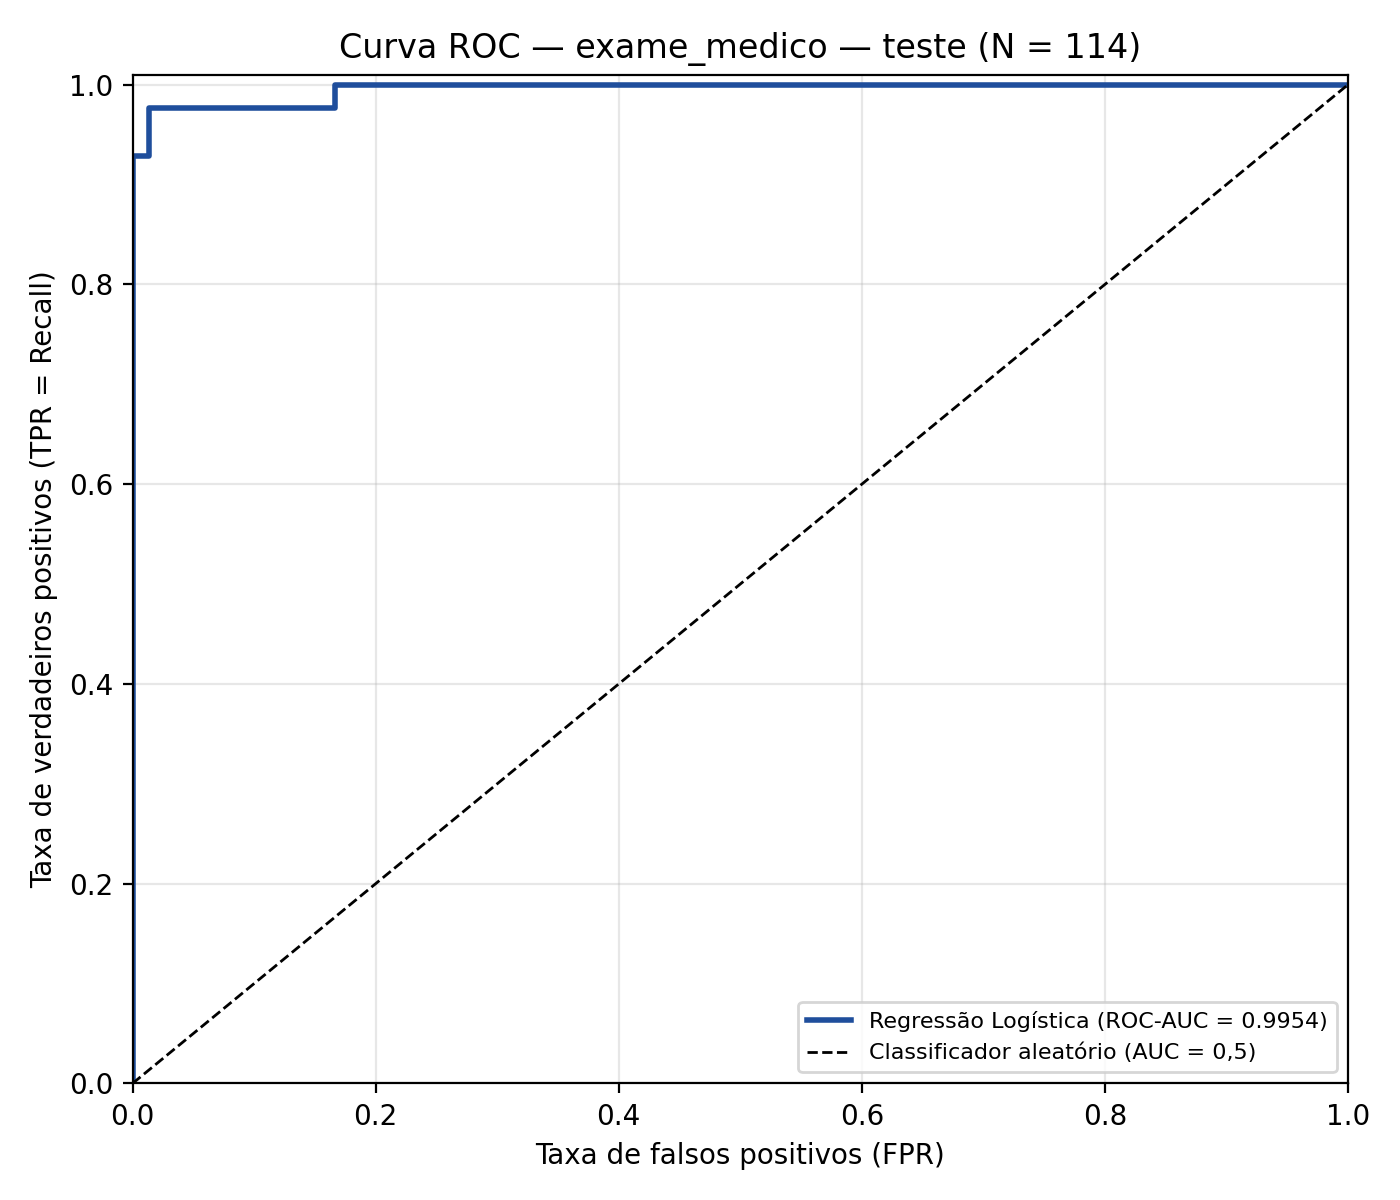

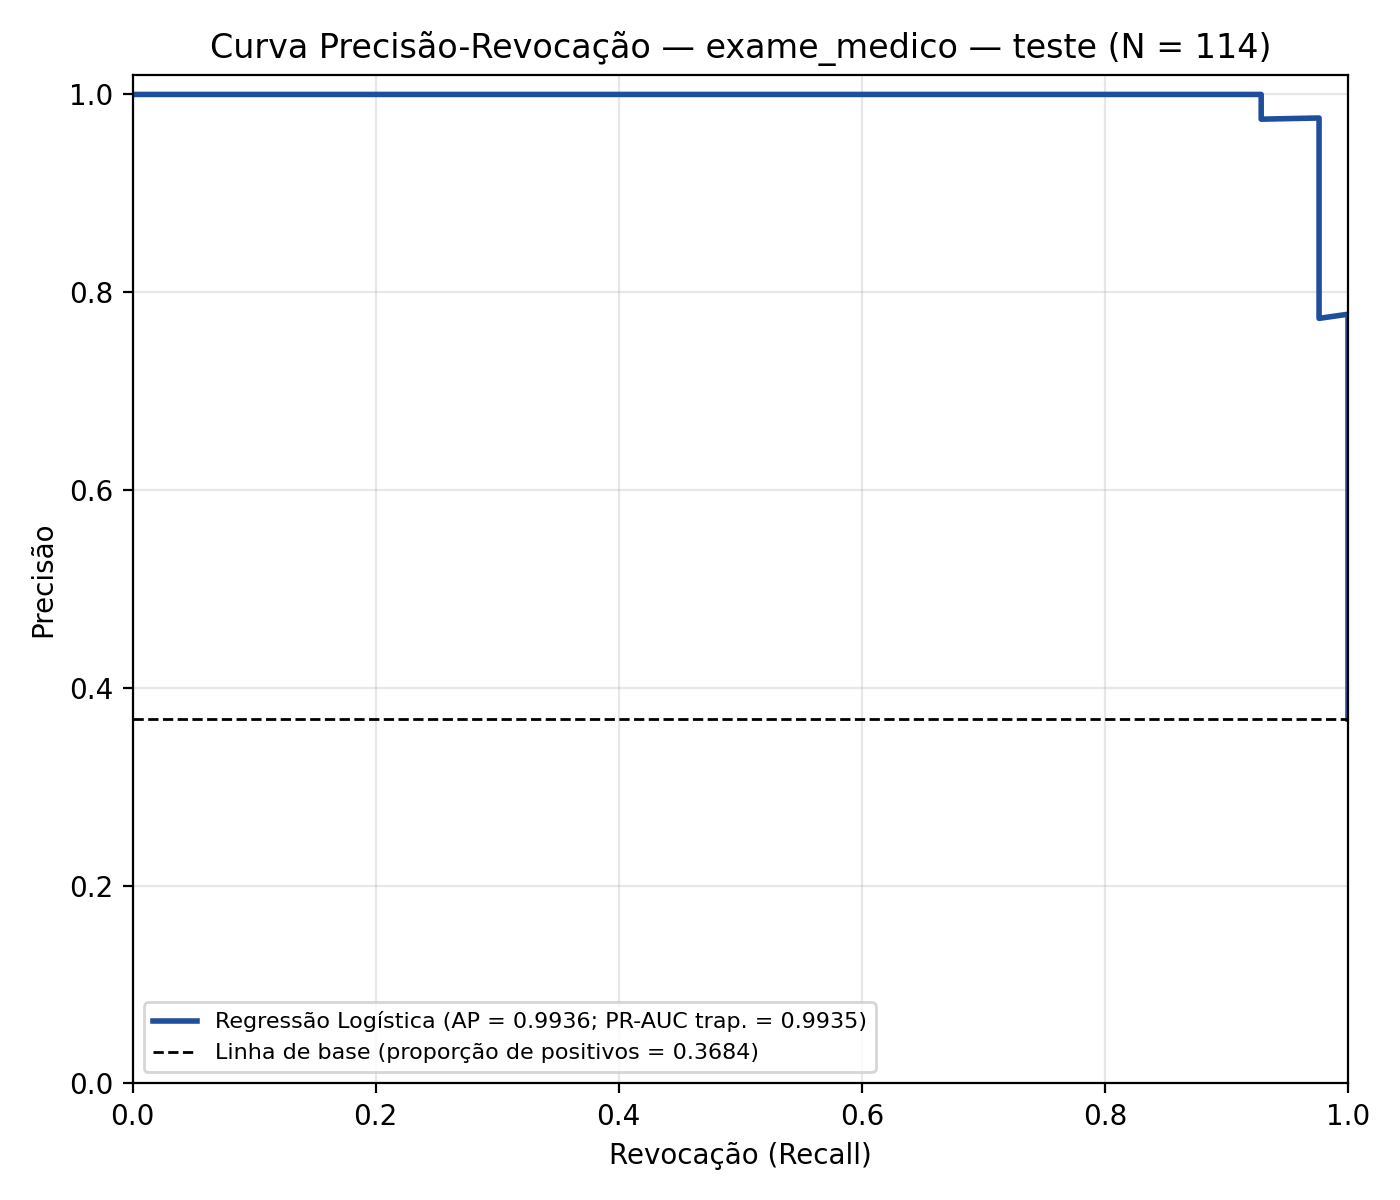

In [12]:
with timed("avaliação no teste"):
    p_test = pipeline.predict_positive(best, X_te)
    resultado_teste = evaluate.comparison_table(y_te, {best_name: p_test})
resultado_teste.insert(1, "conjunto", "teste")
table(resultado_teste, "resultado_teste")
n_te = len(y_te)
show(evaluate.plot_confusion(y_te, p_test, cfg, OUT / "05_matriz_confusao_teste.png",
                             f"Matriz de confusão — {best_name} — teste"))
show(evaluate.plot_roc(y_te, {best_name: p_test}, OUT / "06_curva_roc_teste.png",
                       f"Curva ROC — {DOMAIN} — teste (N = {n_te})"))
show(evaluate.plot_pr(y_te, {best_name: p_test}, OUT / "07_curva_pr_teste.png",
                      f"Curva Precisão-Revocação — {DOMAIN} — teste (N = {n_te})"))

## 10. SHAP beeswarm do melhor modelo (amostra do teste)

[tempo] SHAP: 0.5 s


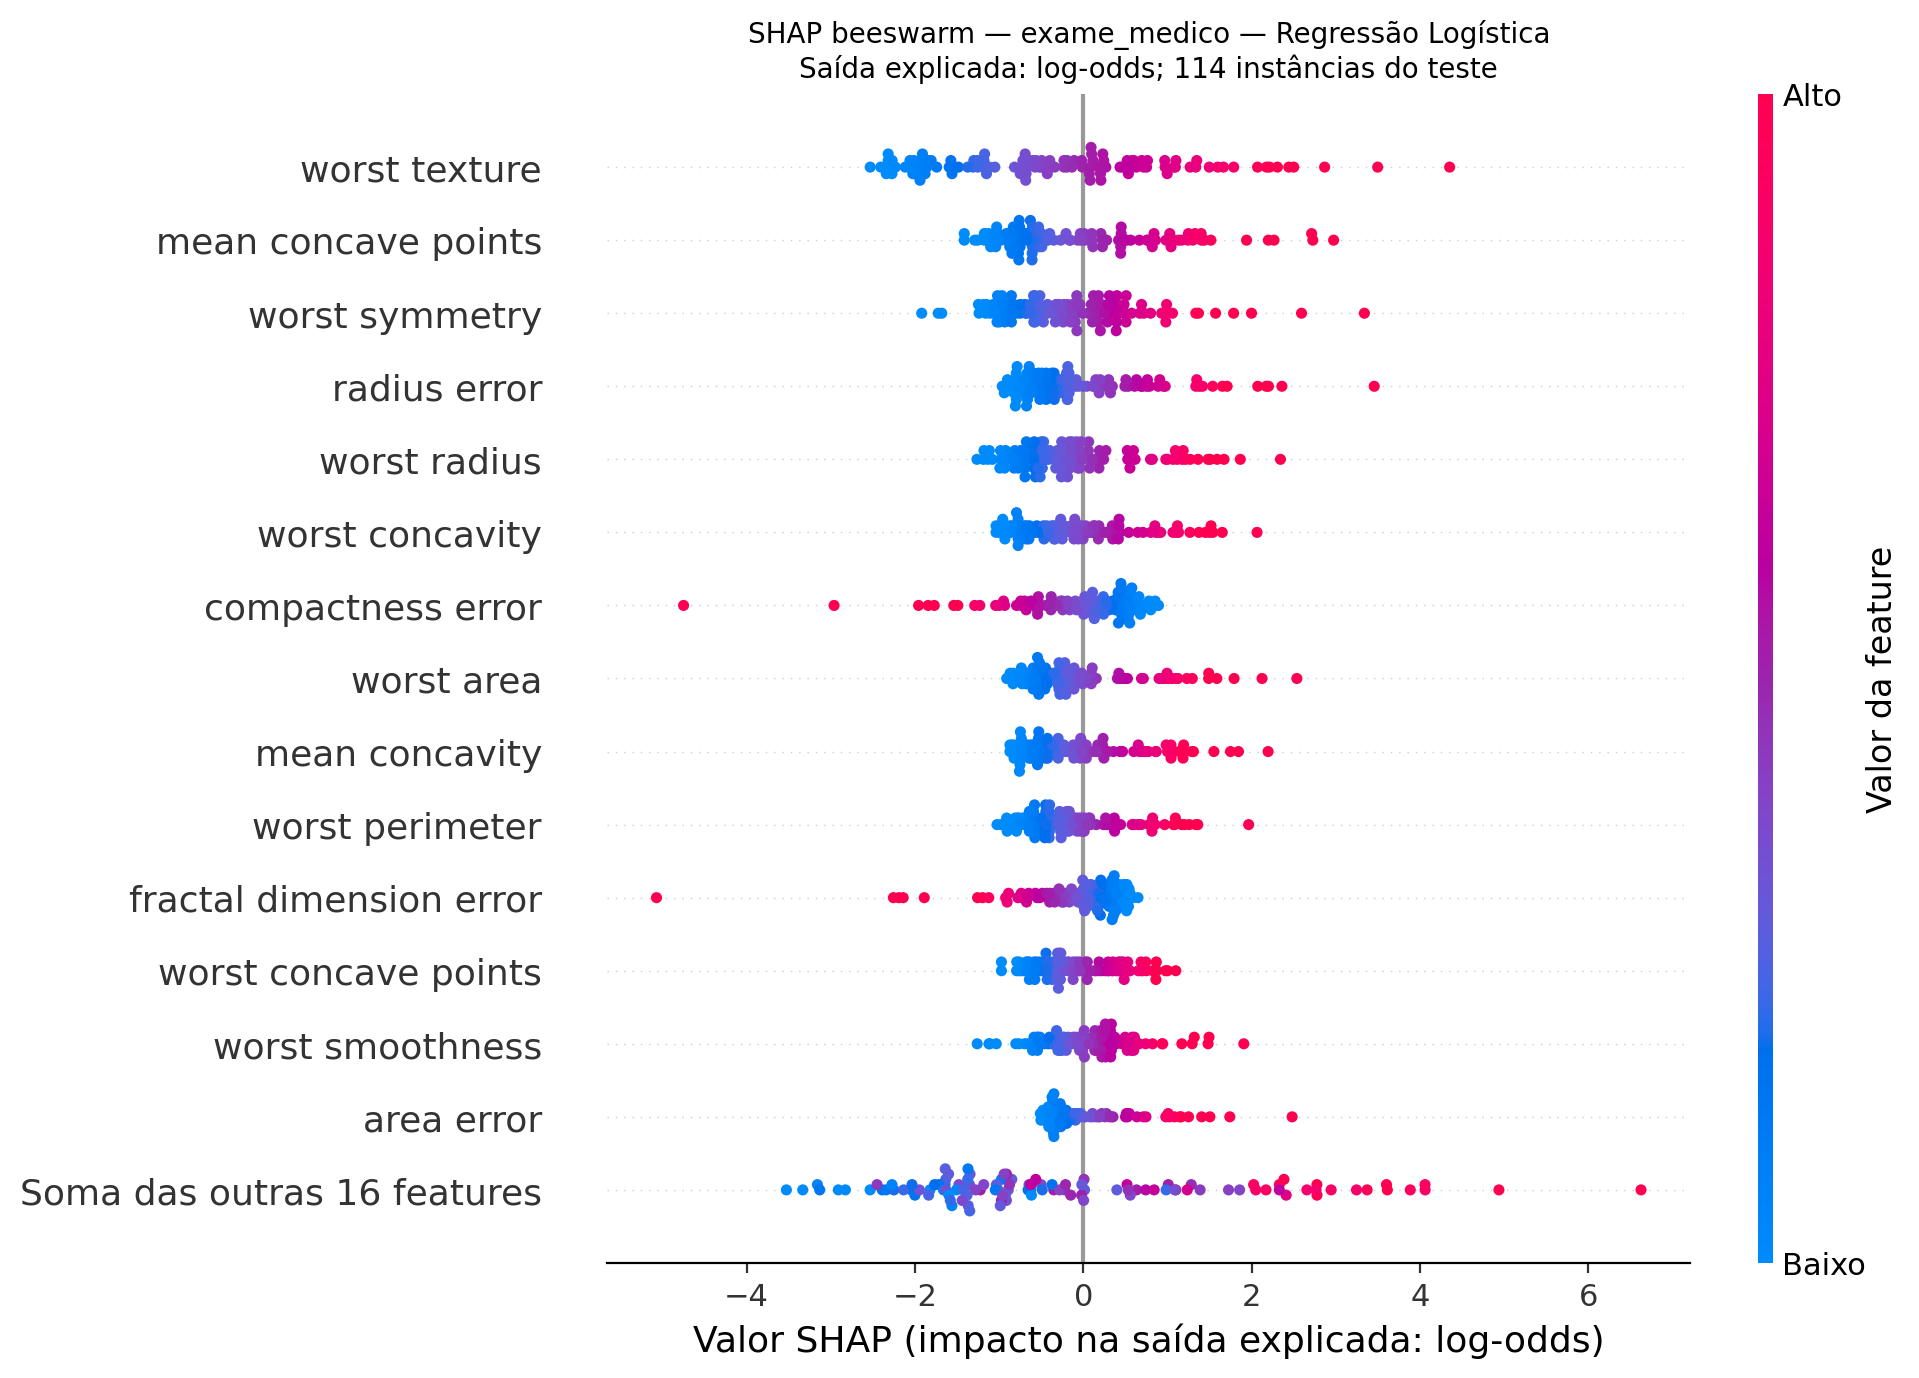

Domínio: exame_medico
Modelo explicado: Regressão Logística (LogisticRegression)
Explainer: LinearExplainer (interventional)
Saída do modelo explicada: log-odds (escala linear) da classe positiva da Regressão Logística
Dados explicados: 114 instâncias aleatórias do conjunto de TESTE (random_state=42), transformadas pelo pré-processamento do pipeline
Conjunto de fundo (background): 100 instâncias aleatórias do TREINO
Número de features após o pré-processamento: 30
Beeswarm: max_display=15; cor = valor da feature (vermelho alto, azul baixo); eixo X = contribuição SHAP para a saída explicada


,posicao,feature,media_abs_shap,correlacao_valor_shap,leitura
0,1,worst texture,1.1791,1.0,valores altos aumentam a saída
1,2,mean concave points,0.8246,1.0,valores altos aumentam a saída
2,3,worst symmetry,0.6661,1.0,valores altos aumentam a saída
3,4,radius error,0.6407,1.0,valores altos aumentam a saída
4,5,worst radius,0.6103,1.0,valores altos aumentam a saída
5,6,worst concavity,0.5825,1.0,valores altos aumentam a saída
6,7,compactness error,0.5674,-1.0,valores altos diminuem a saída
7,8,worst area,0.5582,1.0,valores altos aumentam a saída
8,9,mean concavity,0.5568,1.0,valores altos aumentam a saída
9,10,worst perimeter,0.4912,1.0,valores altos aumentam a saída


In [13]:
with timed("SHAP"):
    shap_res = explain.explain_model(DOMAIN, best_name, best, X_tr, X_te, OUT,
                                     OUT / "08_shap_beeswarm.png")
show(OUT / "08_shap_beeswarm.png")
print("\n".join(shap_res["info"]))
display(evaluate.round_table(shap_res["top10"]))

## 11. Parte 1 aplicada ao melhor modelo

Cortes escolhidos **somente na validação** e aplicados ao teste **sem ajuste**.

t1 = 0.10 | t2 = 0.21  (max_fn_rate = 0.01 sobre positivos, max_fp_rate = 0.1 sobre negativos)


,t1,t2,volume_manual,cobertura_automatica,fn_auto,fn_auto_sobre_positivos,fp_auto,fp_auto_sobre_negativos,violacao,viavel
0,0.10,0.21,0.0614,0.9386,0,0.0,7,0.0986,0.0,True
1,0.10,0.22,0.0614,0.9386,0,0.0,7,0.0986,0.0,True
2,0.10,0.23,0.0614,0.9386,0,0.0,7,0.0986,0.0,True
3,0.10,0.24,0.0614,0.9386,0,0.0,7,0.0986,0.0,True
4,0.10,0.25,0.0614,0.9386,0,0.0,7,0.0986,0.0,True
5,0.10,0.26,0.0702,0.9298,0,0.0,6,0.0845,0.0,True
6,0.09,0.21,0.0702,0.9298,0,0.0,7,0.0986,0.0,True
7,0.09,0.22,0.0702,0.9298,0,0.0,7,0.0986,0.0,True
8,0.09,0.23,0.0702,0.9298,0,0.0,7,0.0986,0.0,True
9,0.09,0.24,0.0702,0.9298,0,0.0,7,0.0986,0.0,True


,faixa,regra,n,pct_populacao_sobre_N,n_positivos,pct_positivos_sobre_n_faixa,n_negativos,pct_negativos_sobre_n_faixa
0,Negativa automática,p < t1,58,50.88,0,0.00,58,100.00
1,Análise manual,t1 ≤ p < t2,7,6.14,1,14.29,6,85.71
2,Positiva automática,p ≥ t2,49,42.98,42,85.71,7,14.29
3,Total,"t1 = 0.1, t2 = 0.21",114,100.00,43,37.72,71,62.28


,metrica,valor,valor_pct,numerador,denominador,descricao_denominador,descricao
0,fn_auto,0.0000,NaN,0,<NA>,— (contagem),positivos classificados automaticamente como n...
1,fn_auto_sobre_positivos,0.0000,0.00,0,43,total de positivos,proporção dos positivos que caíram na faixa ne...
2,fn_auto_sobre_N,0.0000,0.00,0,114,N (total de instâncias),proporção de N que é positivo e caiu na faixa ...
3,fp_auto,7.0000,NaN,7,<NA>,— (contagem),negativos classificados automaticamente como p...
4,fp_auto_sobre_negativos,0.0986,9.86,7,71,total de negativos,proporção dos negativos que caíram na faixa po...
5,fp_auto_sobre_N,0.0614,6.14,7,114,N (total de instâncias),proporção de N que é negativo e caiu na faixa ...
6,cobertura_automatica,0.9386,93.86,107,114,N (total de instâncias),proporção de N decidida automaticamente (fora ...
7,volume_manual,0.0614,6.14,7,114,N (total de instâncias),proporção de N encaminhada à análise manual


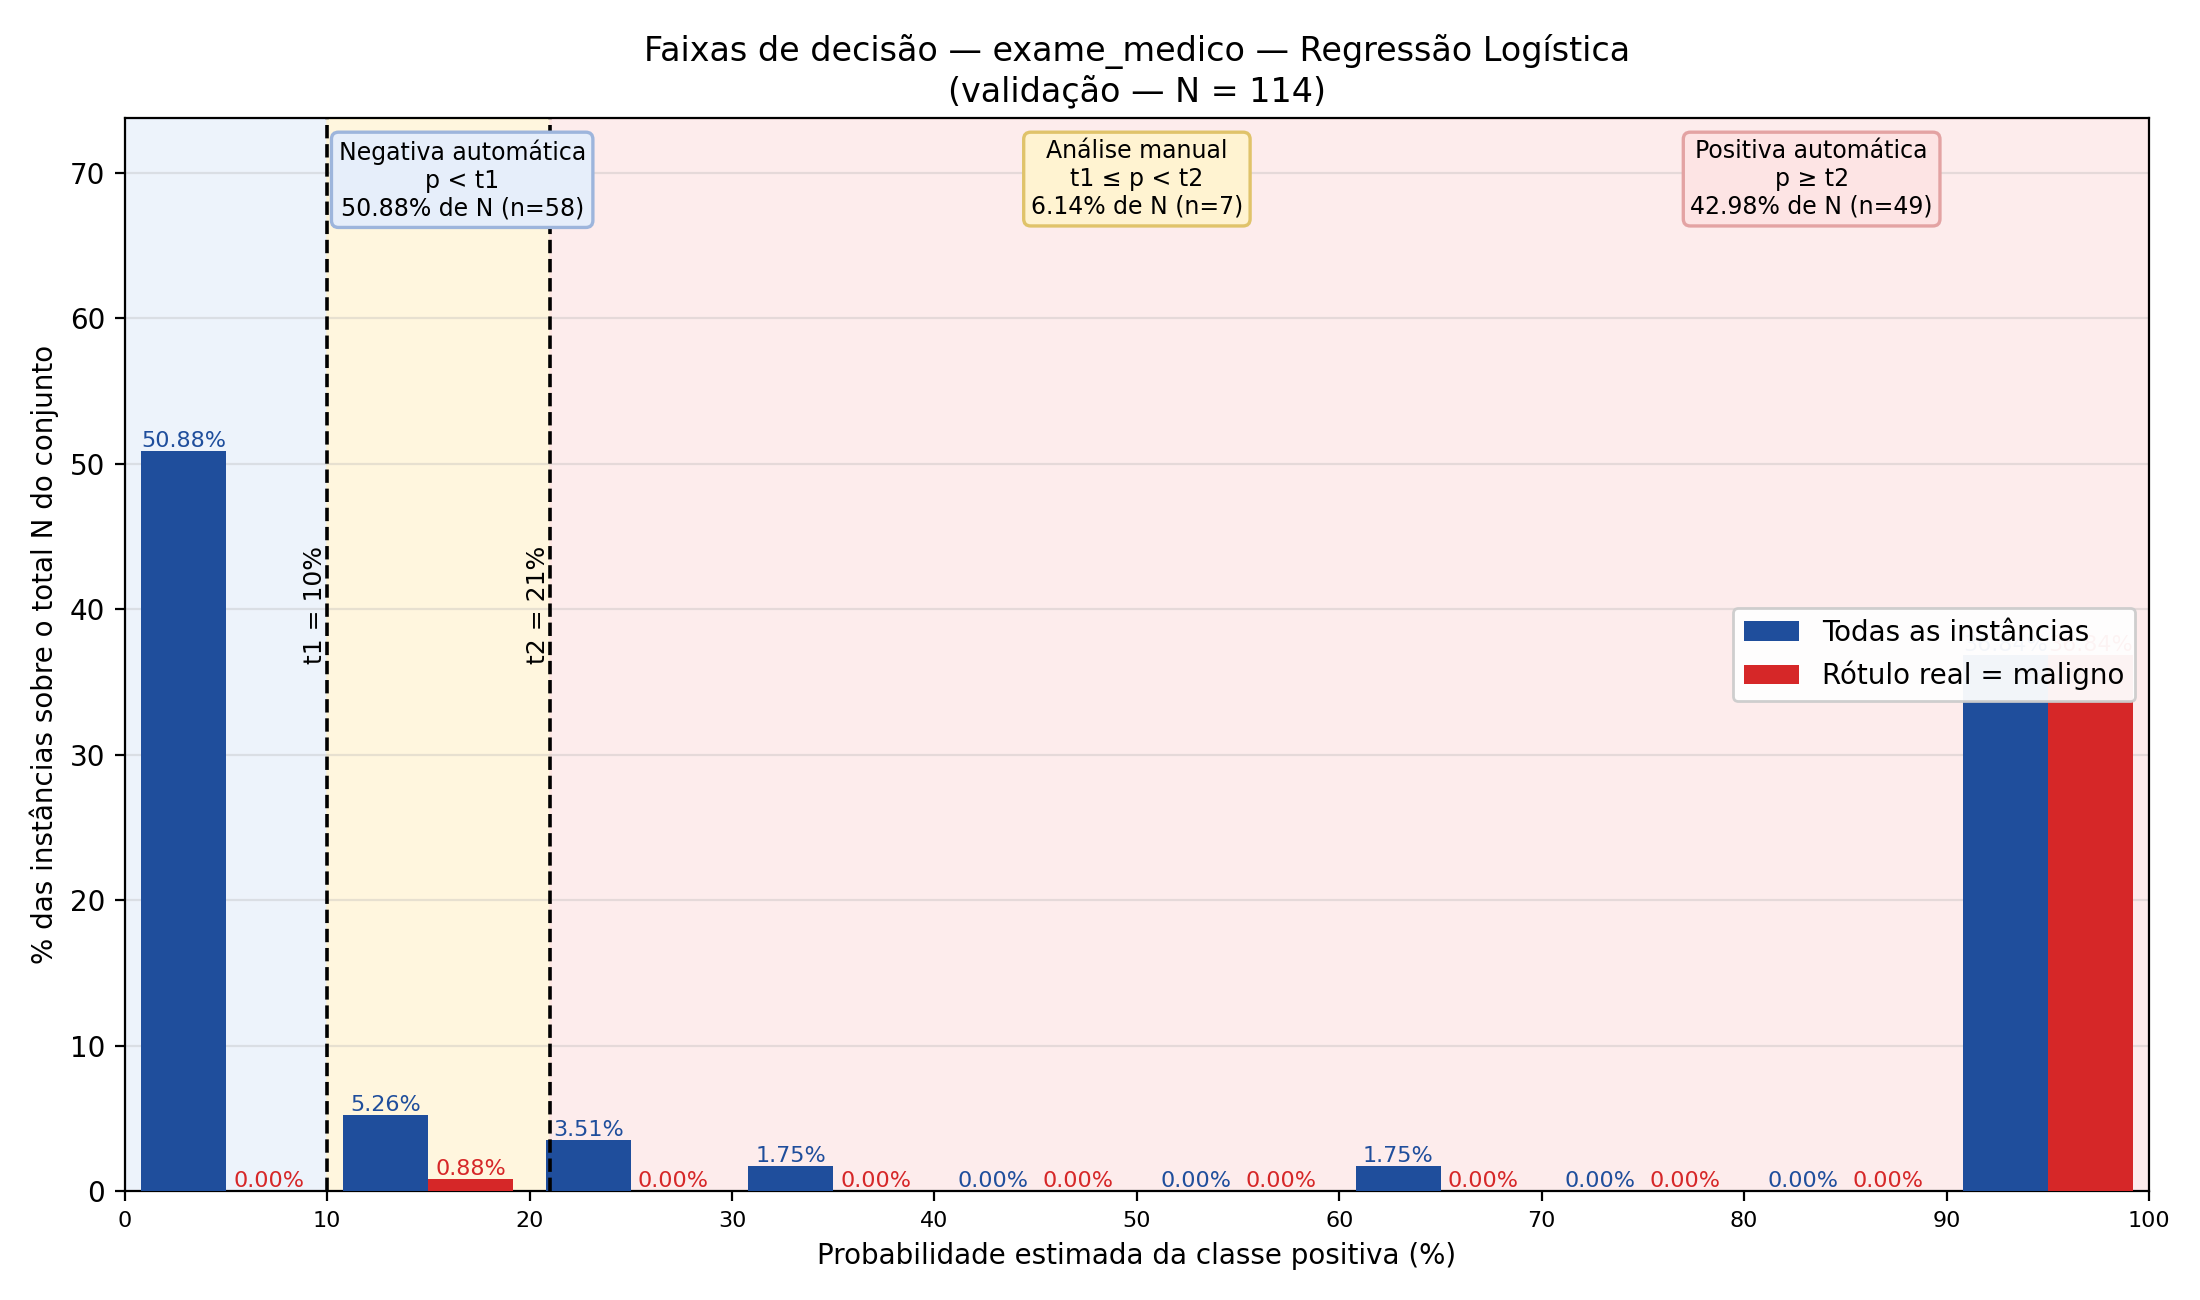

In [14]:
p_val = val_probas[best_name]
(t1, t2), rep_val, tradeoff = cutoff_hist.choose_cutoffs(
    y_val, p_val, cfg["max_fn_rate"], cfg["max_fp_rate"])
print(f"t1 = {t1:.2f} | t2 = {t2:.2f}  (max_fn_rate = {cfg['max_fn_rate']} sobre positivos, "
      f"max_fp_rate = {cfg['max_fp_rate']} sobre negativos)")
table(tradeoff, "faixas/tradeoff_validacao")
table(rep_val["faixas"], "faixas/band_report_validacao_faixas")
table(rep_val["erros"], "faixas/band_report_validacao_erros")
fig, _ = cutoff_hist.plot_cutoff_histogram(
    y_val, p_val, cfg["bin_width"], t1, t2, cfg["positive_label"],
    f"Faixas de decisão — {DOMAIN} — {best_name}", FX / "09_histograma_faixas_validacao.png",
    dataset_name="validação")
plt.close(fig)
show(FX / "09_histograma_faixas_validacao.png")

,faixa,regra,n,pct_populacao_sobre_N,n_positivos,pct_positivos_sobre_n_faixa,n_negativos,pct_negativos_sobre_n_faixa
0,Negativa automática,p < t1,66,57.89,1,1.52,65,98.48
1,Análise manual,t1 ≤ p < t2,3,2.63,0,0.00,3,100.00
2,Positiva automática,p ≥ t2,45,39.47,41,91.11,4,8.89
3,Total,"t1 = 0.1, t2 = 0.21",114,100.00,42,36.84,72,63.16


,metrica,valor,valor_pct,numerador,denominador,descricao_denominador,descricao
0,fn_auto,1.0000,NaN,1,<NA>,— (contagem),positivos classificados automaticamente como n...
1,fn_auto_sobre_positivos,0.0238,2.38,1,42,total de positivos,proporção dos positivos que caíram na faixa ne...
2,fn_auto_sobre_N,0.0088,0.88,1,114,N (total de instâncias),proporção de N que é positivo e caiu na faixa ...
3,fp_auto,4.0000,NaN,4,<NA>,— (contagem),negativos classificados automaticamente como p...
4,fp_auto_sobre_negativos,0.0556,5.56,4,72,total de negativos,proporção dos negativos que caíram na faixa po...
5,fp_auto_sobre_N,0.0351,3.51,4,114,N (total de instâncias),proporção de N que é negativo e caiu na faixa ...
6,cobertura_automatica,0.9737,97.37,111,114,N (total de instâncias),proporção de N decidida automaticamente (fora ...
7,volume_manual,0.0263,2.63,3,114,N (total de instâncias),proporção de N encaminhada à análise manual


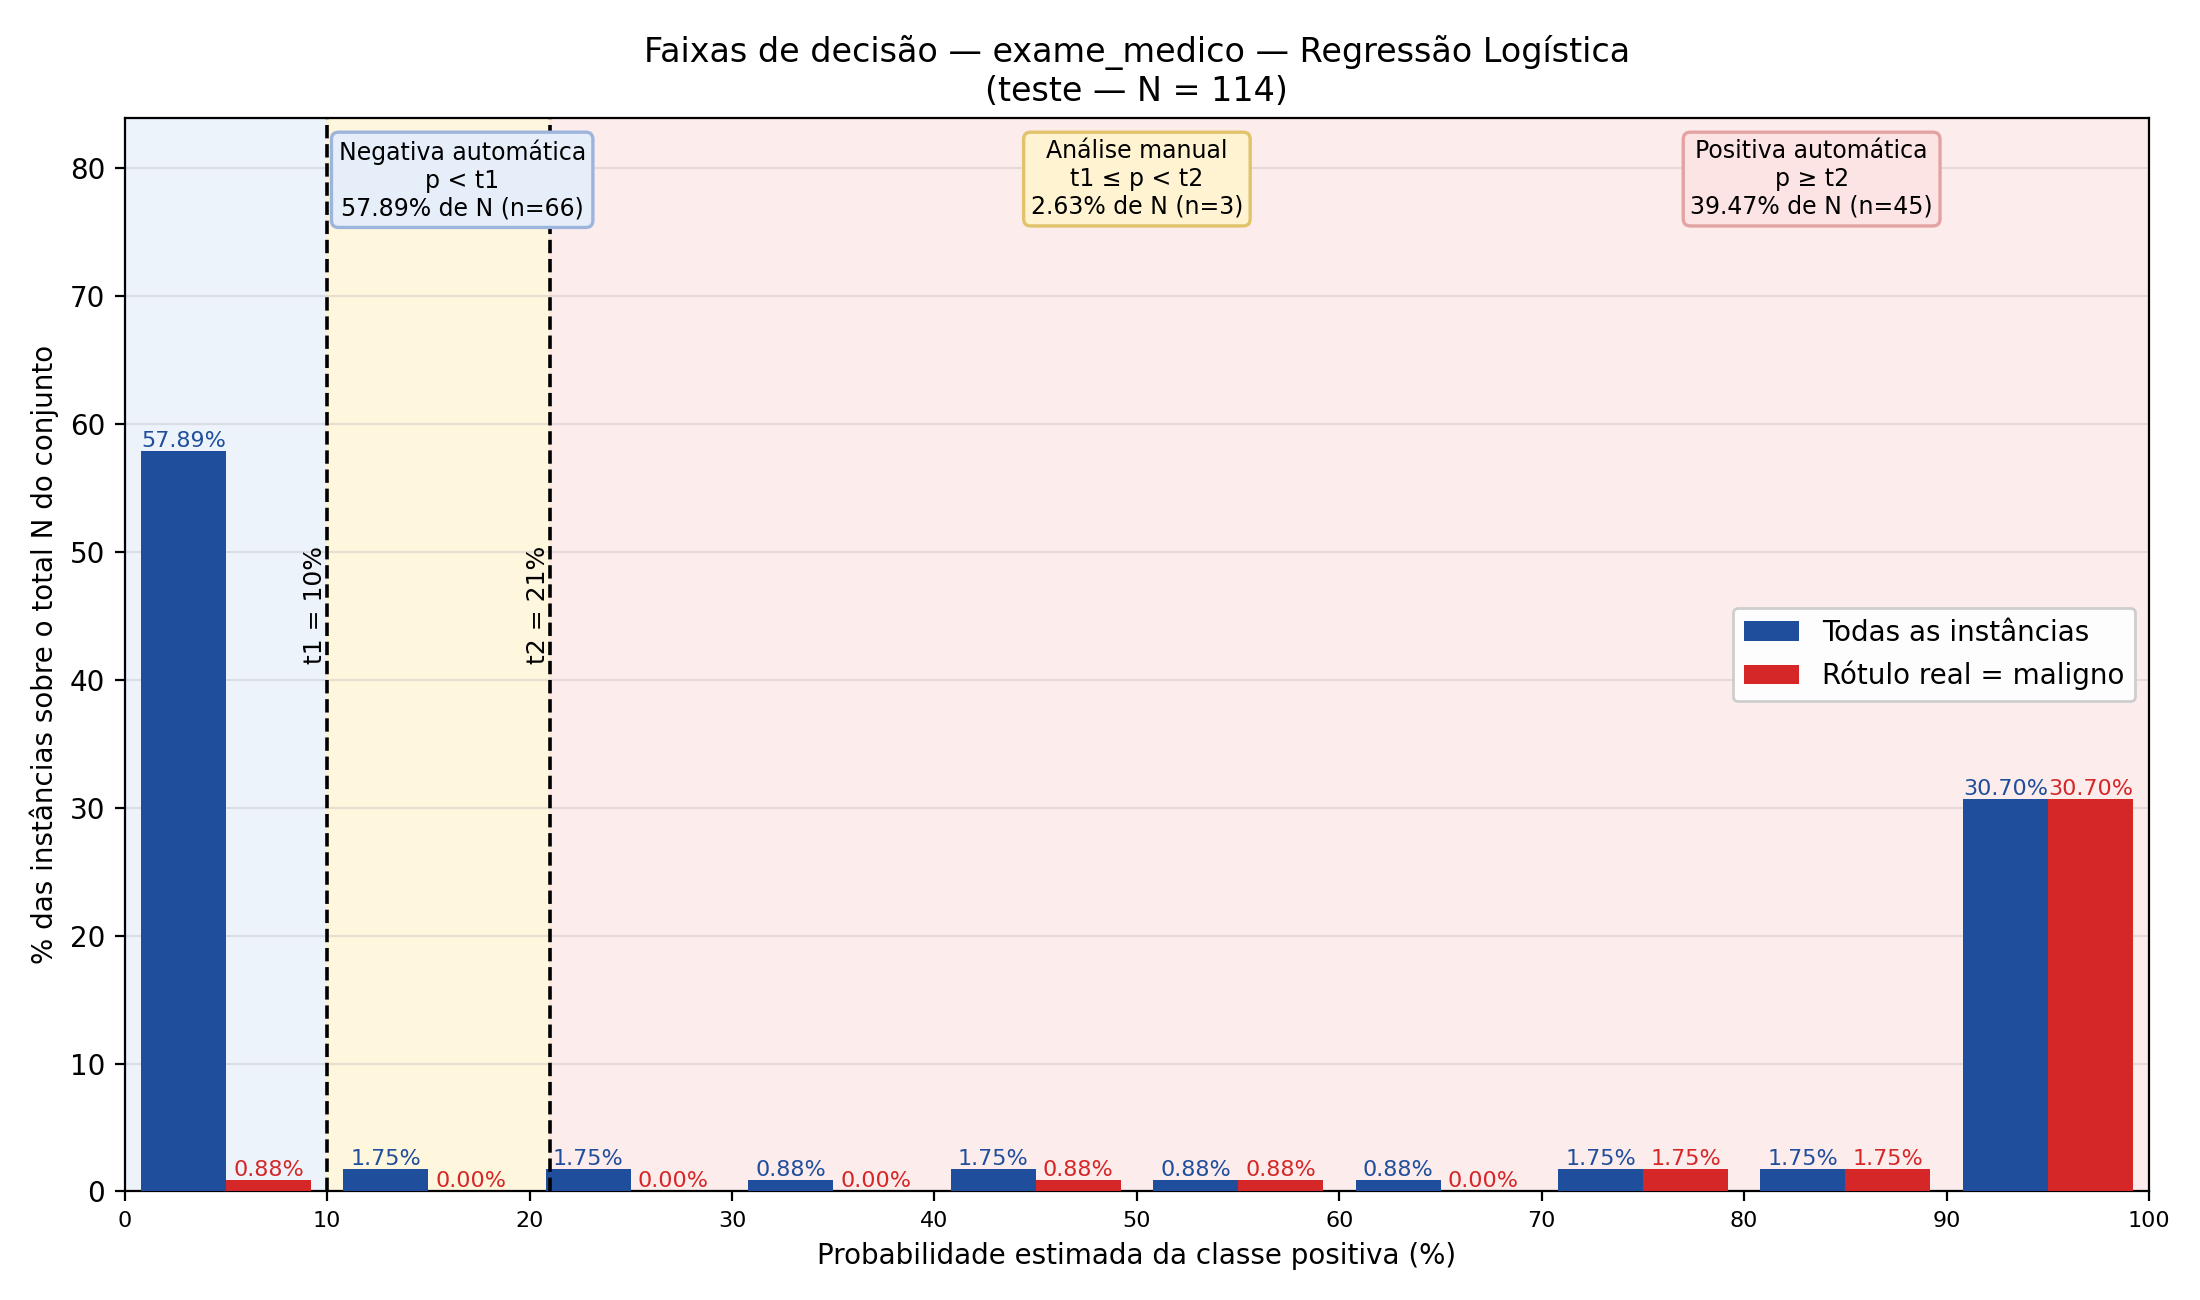

In [15]:
rep_test = cutoff_hist.band_report(y_te, p_test, t1, t2)   # mesmos t1 e t2 da validação
table(rep_test["faixas"], "faixas/band_report_teste_faixas")
table(rep_test["erros"], "faixas/band_report_teste_erros")
fig, _ = cutoff_hist.plot_cutoff_histogram(
    y_te, p_test, cfg["bin_width"], t1, t2, cfg["positive_label"],
    f"Faixas de decisão — {DOMAIN} — {best_name}", FX / "10_histograma_faixas_teste.png",
    dataset_name="teste")
plt.close(fig)
show(FX / "10_histograma_faixas_teste.png")
pd.DataFrame({"y_true": y_val, "y_proba": p_val}).to_csv(OUT / "preds_validacao.csv", index=False)
pd.DataFrame({"y_true": y_te, "y_proba": p_test}).to_csv(OUT / "preds_teste.csv", index=False)

## 12. Resumo numérico

In [16]:
tempos = pd.DataFrame({"etapa": list(pipeline.TIMINGS), "segundos": list(pipeline.TIMINGS.values())})
blocos = [
    ("Balanceamento", balanceamento),
    ("Split 60/20/20", pipeline.split_table(splits)),
    (f"Hiperparâmetros vencedores (CV {config.CV_SPLITS} folds, {cfg['target_metric']})",
     hiperparametros),
    (f"Comparação na validação (limiar = {T})", comparacao),
    ("Melhor modelo", selecao),
    (f"Resultado no teste (limiar = {T})", resultado_teste),
    ("SHAP — informações", shap_res["info"]),
    ("SHAP — top 10 features (média |SHAP|)", shap_res["top10"]),
    ("Cortes (escolhidos na validação)",
     [f"t1 = {t1:.2f}", f"t2 = {t2:.2f}",
      f"max_fn_rate = {cfg['max_fn_rate']} (sobre positivos)",
      f"max_fp_rate = {cfg['max_fp_rate']} (sobre negativos)"]),
    ("Trade-off (10 melhores pares viáveis, validação)", tradeoff),
    ("band_report — validação — faixas", rep_val["faixas"]),
    ("band_report — validação — erros", rep_val["erros"].drop(columns="descricao")),
    ("band_report — teste — faixas", rep_test["faixas"]),
    ("band_report — teste — erros", rep_test["erros"].drop(columns="descricao")),
    ("Tempo de execução (s)", tempos),
    ("Figuras geradas", FIGS),
]
resumo = evaluate.write_summary(OUT / "resumo_resultados.md",
                                f"Resumo de resultados — {DOMAIN}", blocos)
print("Resumo salvo em", resumo)

Resumo salvo em C:\Users\otavi\OneDrive\Desktop\data science\a2\outputs\exame_medico\resumo_resultados.md
